In [56]:
import geopandas as gpd
import pandas as pd
import numpy as np
from bld_src import config

In [ ]:
## data types: string ='anything in quotes', float = decimal number, int = whole numbers

# lists: defined by square brackets, separated by commas: [a,b,c,d...]
# lists have properties such as .append() 

# dictionaries: defined by curly brackets, consist of key:value pairs: {key1:value1,key2:value2,key3:value3...}
# these are a convenient way to store data and access by the key. for example, the value might be an array of spectral indices and the key used to access might be 'ndvi'. 

# numpy indexing: [row,column] - pattern used to select values from arrays and dataframes



In [2]:
plots = gpd.read_file(config.DATA_RAW / 'Teatown Sites.shp' / 'Points.shp')

In [ ]:
plots = plots[['Name','geometry']]

# separate out trees and sites
trees = plots.loc[plots['Name'].str.contains('Tree')].copy()
sites = plots.loc[~plots['Name'].str.contains('Tree')].copy()
sites.to_file(config.DATA_PROCESSED / 'teatown_sites_points.gpkg')

# clean name column (list comprehension)
trees['Name'] = [n.split(' ')[1] for n in trees['Name']]
trees['Name'] = trees['Name'].astype(int)

In [123]:
eval = pd.read_excel(config.DATA_RAW / 'BLD_Evaluation_2026_Data.xlsx')
# merge points with health data
trees_eval = trees.merge(eval,left_on='Name',right_on='Tree #')
trees_eval = trees_eval.drop(columns={'Tree #'})
# rename columns
trees_eval.columns = ['Name','geometry','dbh','species','crown_class','leaf_density','dieback_overall','leaf_discolor','dead_branch_main','dead_branch_fine','no_symptom','banded','curled','bbd_present']
#trees_eval.to_file(config.DATA_PROCESSED / 'teatown_trees_eval.gpkg')

## basal area column
trees_eval['basal_area'] = config.BA_CONVERSION * trees_eval['dbh']**2

# fix one row where 33 was entered by mistake, change to 3.0
trees_eval.loc[trees_eval['curled']==33.0,'curled'] = 3.0

# write to file
trees_eval.to_file(config.DATA_PROCESSED / 'teatown_trees_eval.gpkg')

In [108]:

trees_eval.columns


Index(['Name', 'geometry', 'dbh', 'species', 'crown_class', 'leaf_density',
       'dieback_overall', 'leaf_discolor', 'dead_branch_main',
       'dead_branch_fine', 'no_symptom', 'banded', 'curled', 'bbd_present',
       'basal_area', 'no_symptom_weighted', 'nonbeech_dieback_weighted',
       'banded_weighted', 'curled_weighted'],
      dtype='object')

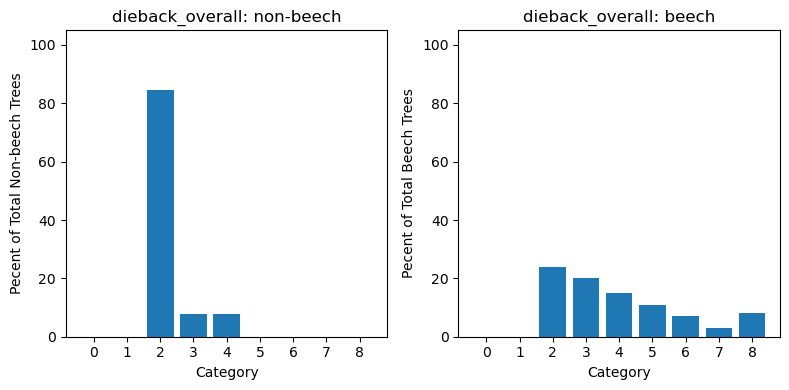

In [137]:
import matplotlib.pyplot as plt

column_name = 'dieback_overall' #### can plot 'dieback_overall' or 'leaf_density'

categories = [0,1,2,3,4,5,6,7,8] # all possible values for metric

fig, axes = plt.subplots(1,2,figsize=(8,4))

# get number of nonbeech in each category
nonbeech = trees_eval.loc[trees_eval['species']!='Beech'][column_name].value_counts().reindex(categories,fill_value=0)
# convert to percent of total nonbeech
nonbeech_pct = (nonbeech / nonbeech.sum())*100
# make bar chart
axes[0].bar(nonbeech_pct.index,nonbeech_pct.values)
axes[0].set_xlabel('Category')
axes[0].set_xticks(categories)
axes[0].set_ylabel('Pecent of Total Non-beech Trees')
axes[0].set_title(f'{column_name}: non-beech')
axes[0].set_ylim(0,105)

# get number of beech in each category
beech_only = trees_eval.loc[trees_eval['species']=='Beech'][column_name].value_counts().reindex(categories,fill_value=0)
# convert to percent of total beech
beech_pct = (beech_only / beech_only.sum())*100
# make bar chart
axes[1].bar(beech_only.index,beech_only.values)
axes[1].set_xlabel('Category')
axes[1].set_xticks(categories)
axes[1].set_title(f'{column_name}: beech')
axes[1].set_ylabel('Pecent of Total Beech Trees')
axes[1].set_ylim(0,105)

plt.tight_layout()
plt.show()

## note: to save plots, hover mouse over plot and click the save icon that appears in upper right

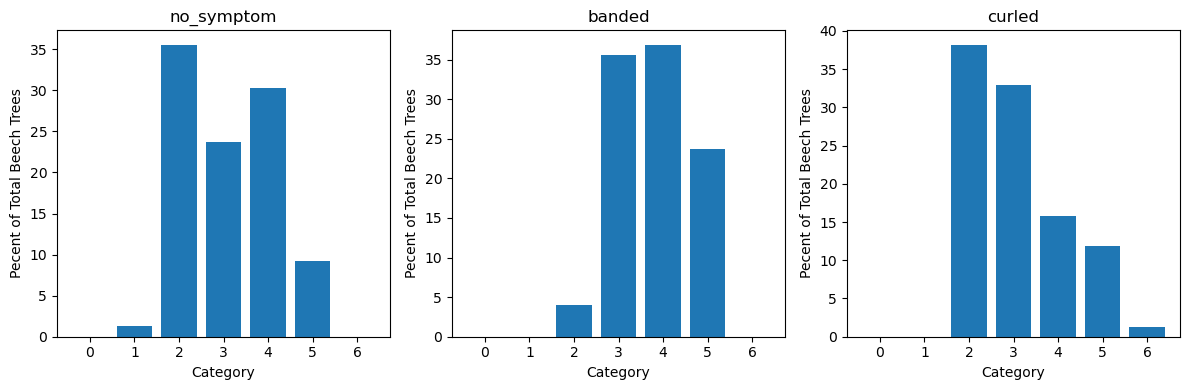

In [ ]:
## plot beech tree metrics only

# select just beech trees from dataframe
beech_only = trees_eval.loc[trees_eval['species']=='Beech'].copy()


## set up plot with 1 row and 3 columns
fig, axes = plt.subplots(1,3,figsize=(12,4))

# for each column, plot it on the next axes
for c, ax in zip(['no_symptom','banded','curled'],axes):
   
    categories = [0,1,2,3,4,5,6] ## all possible health categories

    # get count trees per category
    counts = beech_only[c].value_counts().reindex(categories,fill_value=0)
    # convert to percent of total number of beech trees
    pct = (counts / counts.sum())*100
    ax.bar(pct.index,pct.values)
    ax.set_xlabel('Category')
    ax.set_title(c)
    ax.set_xticks(categories)
    ax.set_ylabel('Pecent of Total Beech Trees')
   

plt.tight_layout()
plt.show()

In [ ]:
## convert tree-level health metrics to plot-level 

## code nonbeech as 0 for bld metrics
bld_metrics = ['no_symptom','banded','curled']
trees_eval= trees_eval.fillna({m:0.0 for m in bld_metrics})

is_beech = trees_eval['species'] == 'Beech'

# weight metrics by basal area
for m in bld_metrics:
    trees_eval[f'{m}_weighted'] = np.where(is_beech,trees_eval[m]*trees_eval['basal_area'],0.0)
    trees_eval['nonbeech_dieback_weighted'] = np.where(~is_beech,trees_eval['dieback_overall']*trees_eval['basal_area'],0.0)

# make basal area column for beech only; nonbeech gets set to 0
trees_eval['beech_ba'] = np.where(is_beech,trees_eval['basal_area'],0.0)

In [ ]:
### this cell groups trees by plot and calculates plot-level health metrics
### will only run if plot column exists!

plot_col = ' '

# group trees by plot
grouped = trees_eval.groupby(plot_col)
out = pd.DataFrame({'total_ba':grouped['basal_area'].sum(),  ## total basal area per plot
                'beech_ba' : grouped['beech_ba'].sum(), # total beech basal area per plot
                    'nonbeech_ba': grouped['nonbeech_ba'].sum(),   # nonbeech basal area per plot
                    'nonbeech_dieback': grouped['nonbeech_dieback_weighted'].sum(),  ## plot level health for non-beech
                    'n_beech': grouped['species'].apply(lambda x: (x=='Beech').sum()), # number of beech per plot
                    'n_nonbeech': grouped['species'].apply(lambda x: (x!='Beech').sum())})  # number of nonbeech per plot
for m in bld_metrics:
    out[m] = grouped[f'{m}_weighted'].sum()   ## sum of weight beech health metrics per plot (no symptom, banded, curled)

# beech abundance
out['beech_rel_ba'] = out['beech_ba'] / out['total_ba']  

# weighted summed per-tree metrics divided by plot basal area
for m in bld_metrics:
    out[f'{m}_burden'] = out[m] / out['total_ba'] ## plot wide disease burden metric; describes what sentinel detects
    out[f'{m}_mean_severity'] = out[m] / out['beech_ba'] ## beech only severity metric; describes extent of disease 

out['nonbeech_dieback_burden'] = out['nonbeech_dieback'] / out['total_ba'] # describes health of non-beech trees in plot

out = out.reset_index()


